In [10]:
# import packages
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
from torchsummary import summary
import random
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd
from torch.utils.tensorboard import SummaryWriter


In [11]:
# check if the gpu is available or not
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [12]:
path = "/kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set"

In [13]:
# Check inside the dataset directory how many file and folders are there
for dirpath, dirnames, filenames in os.walk(os.path.join(path, 'images')):
    print(f'There are {len(filenames)} files and {len(dirnames)} directories in [{dirpath}]')
# Check inside the gt semantic
for dirpath, dirnames, filenames in os.walk(os.path.join(path, 'gt/semantic')):
    print(f'There are {len(filenames)} files and {len(dirnames)} directories in [{dirpath}]')

There are 400 files and 0 directories in [/kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set/images]
There are 1 files and 2 directories in [/kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set/gt/semantic]
There are 400 files and 0 directories in [/kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set/gt/semantic/label_images]
There are 400 files and 0 directories in [/kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set/gt/semantic/label_me_xml]


In [14]:
# list all the images from the original_images directory later on we can use them
org_imgs = os.listdir(os.path.join(path, 'images'))
print(f'There are {len(org_imgs)} images in [original_images] directory')

There are 400 images in [original_images] directory


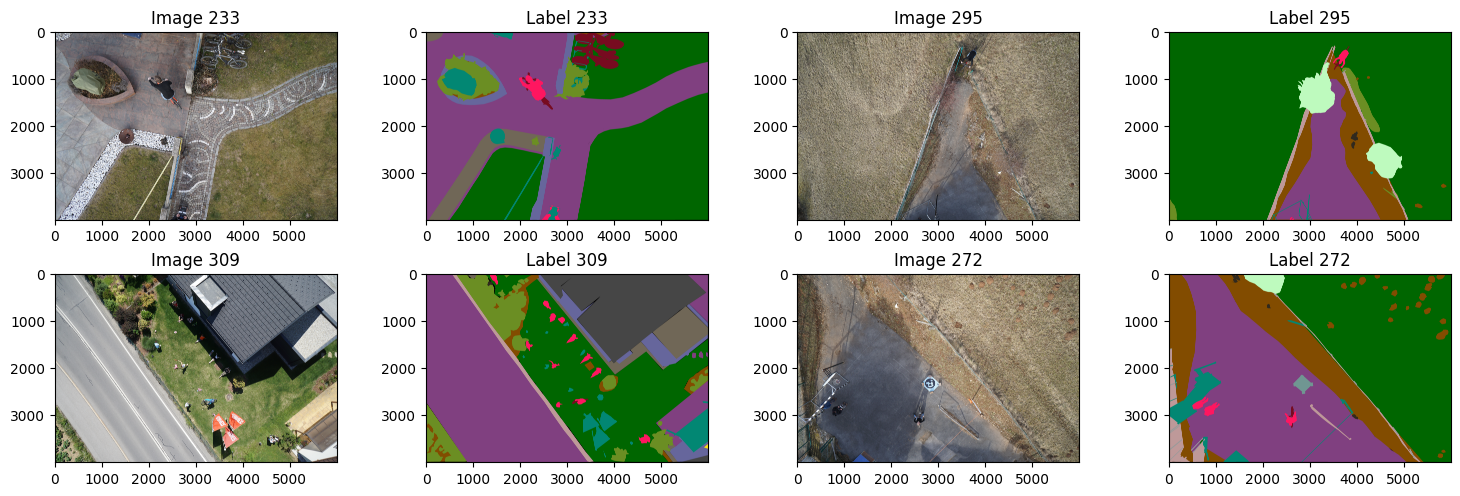

In [15]:
# reading images and labels by index later
def get_img_label(idx):
  img_path = org_imgs[idx]
  img = Image.open(os.path.join(path, 'images', img_path))
  label = Image.open(os.path.join(path, 'gt/semantic/label_images', f'{img_path.split('.')[0]}.png'))
  return img, label

# plot some random images with the labes side by side
fig, ax = plt.subplots(2, 4, figsize=(15, 5))

# First
random_idx = np.random.randint(0, len(org_imgs))
img, label = get_img_label(random_idx)
ax[0][0].imshow(img)
ax[0][0].set_title(f'Image {random_idx}')
ax[0][1].imshow(label)
ax[0][1].set_title(f'Label {random_idx}')

# Second
random_idx = np.random.randint(0, len(org_imgs))
img, label = get_img_label(random_idx)
ax[0][2].imshow(img)
ax[0][2].set_title(f'Image {random_idx}')
ax[0][3].imshow(label)
ax[0][3].set_title(f'Label {random_idx}')

# Third
random_idx = np.random.randint(0, len(org_imgs))
img, label = get_img_label(random_idx)
ax[1][0].imshow(img)
ax[1][0].set_title(f'Image {random_idx}')
ax[1][1].imshow(label)
ax[1][1].set_title(f'Label {random_idx}')

# Fourth
random_idx = np.random.randint(0, len(org_imgs))
img, label = get_img_label(random_idx)
ax[1][2].imshow(img)
ax[1][2].set_title(f'Image {random_idx}')
ax[1][3].imshow(label)
ax[1][3].set_title(f'Label {random_idx}')

plt.tight_layout()

In [16]:
# split the dataset in training (70%), validation (20%), and tesing (10%)
generator = torch.Generator().manual_seed(0) # keep the randomnes constant for the development and testing
training_imgs, validation_imgs, testing_imgs = torch.utils.data.random_split(org_imgs, [0.7, 0.2, 0.1])
print(f'{len(training_imgs)} images for training \n{len(validation_imgs)} images for validation \n{len(testing_imgs)} images for testinng.')
print(f'Total number of images: {len(org_imgs)}')

280 images for training 
80 images for validation 
40 images for testinng.
Total number of images: 400


In [18]:
# Create a class to load the dataset
class MyDataset(torch.utils.data.Dataset):
  def __init__(self, data_dir, img_list, transform=None):
    self.data_dir = data_dir
    self.img_list = img_list
    self.transform = transform

  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, index):
    img = Image.open(os.path.join(self.data_dir, 'images', self.img_list[index])).convert("RGB")
    mask = Image.open(os.path.join(self.data_dir, 'gt/semantic/label_images', f'{self.img_list[index].split('.')[0]}.png')).convert("L")
    if self.transform:
      img, mask = self.transform(img, mask)
    return img, mask

In [19]:
# Add some data augmentaion to the datasets
IMG_SIZE = 224
gl_mean = [0.4441, 0.4431, 0.4013]
gl_std = [0.1898, 0.1837, 0.1954]
def train_transform(img, mask):
    # Resize
    img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = TF.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.NEAREST)
    # Random horizontal flip
    if random.random() > 0.5:
        img = TF.hflip(img)
        mask = TF.hflip(mask)
    # Random rotation
    angle = random.uniform(-10, 10)
    img = TF.rotate(img, angle)
    mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)
    # Convert to tensor
    img = TF.to_tensor(img)
    # mask = TF.to_tensor(mask)
    mask = torch.as_tensor(np.array(mask), dtype=torch.long)

    # Normalize ONLY image
    img = TF.normalize(
        img,
        mean=gl_mean,
        std=gl_std
    )
    return img, mask

def test_transformer(img, mask):
    # Resize
    img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = TF.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.NEAREST)
    # Convert to tensor
    img = TF.to_tensor(img)
    # mask = TF.to_tensor(mask)
    mask = torch.as_tensor(np.array(mask), dtype=torch.long)
    # Normalize ONLY image
    img = TF.normalize(
        img,
        mean=gl_mean,
        std=gl_std
    )
    return img, mask

In [20]:
# Load the trainin, validation and testing dataset
# This might take 12 minuts in the first attempt
train_data = MyDataset(path, training_imgs, train_transform)
val_data = MyDataset(path, validation_imgs, test_transformer)
test_data = MyDataset(path, testing_imgs, test_transformer)
len(train_data), len(val_data), len(test_data)

(280, 80, 40)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.412085..2.963624].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.412085..3.003763].


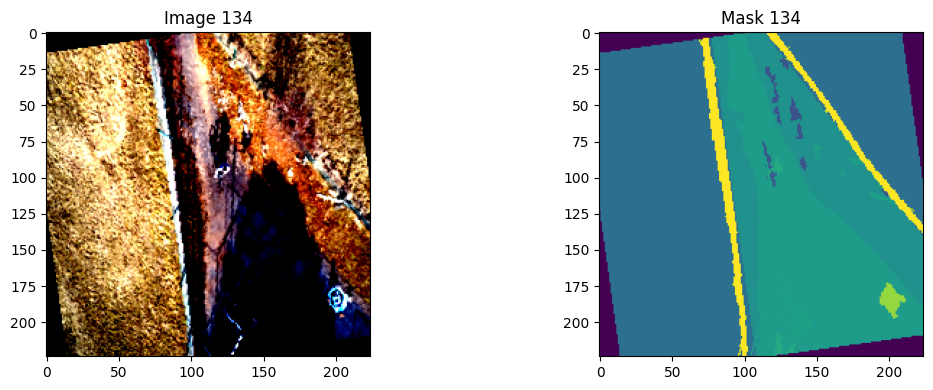

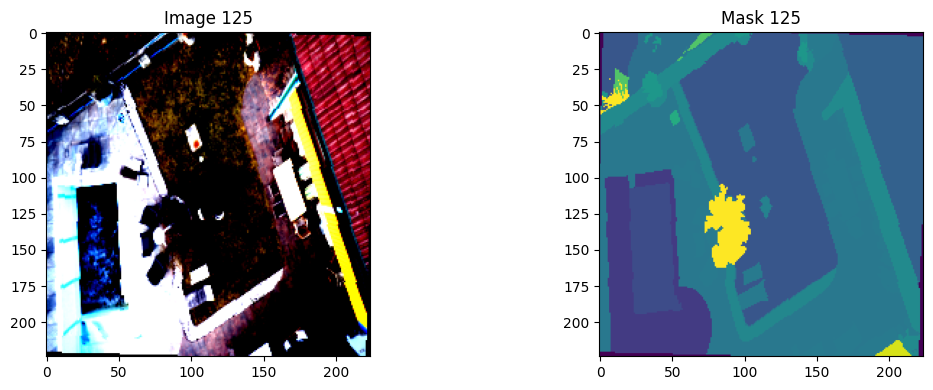

In [23]:
# plot a random training augmented image and the mask to make sure it's working fine
for i in range(2):
  _, ax = plt.subplots(1, 2, figsize=(12, 4))
  idx = np.random.randint(0, len(train_data))
  img, label = train_data.__getitem__(idx)
  ax[0].imshow(img.permute(1, 2, 0))
  ax[0].set_title(f"Image {idx}")
  ax[1].imshow(label)
  ax[1].set_title(f"Mask {idx}")


  plt.tight_layout()


In [25]:
# Create a data loader for training, validation, and testing
batch_size = 32
train_dataloader = torch.utils.data.DataLoader(train_data,
                                               batch_size=batch_size,
                                               shuffle=True,
                                               num_workers=2,
                                               pin_memory=True, # speeds up the transfer of data from CPU to GPU
                                               drop_last=True)
val_dataloader = torch.utils.data.DataLoader(val_data,
                                               batch_size=batch_size,
                                               shuffle=True,
                                               num_workers=2,
                                               pin_memory=True,
                                               drop_last=False)

test_dataloader = torch.utils.data.DataLoader(test_data,
                                               batch_size=batch_size,
                                               shuffle=False,
                                               num_workers=2,
                                               pin_memory=True,
                                               drop_last=False)
print(f"""There are {len(train_dataloader)} training batches
{len(val_dataloader)} validation batches
{len(test_dataloader)} testing batches""")


There are 8 training batches
3 validation batches
2 testing batches


In [27]:
# build the double conve
class DoubleConve_block(nn.Module):
  def __init__(self, in_c, out_c):
     super().__init__()
     self.double_conv = nn.Sequential(
         nn.Conv2d(in_c, out_c, 3, padding=1, stride=1),
         nn.ReLU(),
         nn.Conv2d(out_c, out_c, 3, padding=1, stride=1),
         nn.ReLU()
     )
  def forward(self, x):
    out = self.double_conv(x)
    return out

In [28]:
# Create downsampling block
class Downsampling_block(nn.Module):
  def __init__(self, in_c, out_c):
     super().__init__()
     self.double_conv = DoubleConve_block(in_c, out_c)
     self.max = nn.MaxPool2d(2)
     self.dropout = nn.Dropout2d(0.3)

  def forward(self, x):
    f = self.double_conv(x)
    out = self.max(f)
    out = self.dropout(out)
    return f, out

In [29]:
# Create upsampling block
class Upsampling_block(nn.Module):
  def __init__(self, in_c, out_c):
     super().__init__()
    #  upsample
     self.convt = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2)
     self.drop = nn.Dropout(0.3)
     self.double_block = DoubleConve_block(out_c*2, out_c)
  def forward(self, x, skip):
    up = self.convt(x)
    # concatenate
    concat = torch.cat([up, skip], dim=1)
    # dropout
    out = self.drop(concat) # (out_c + out_c, out_c)
    # Conv2D twice with ReLU activation
    out = self.double_block(out)
    return out


In [30]:
# Build the U-Net Model
class U_Net(nn.Module):
  def __init__(self):
    super(U_Net, self).__init__()
    # input
    # self.input = nn.Conv2d(3, 64, 3, padding=1) # (B, C, H, W)
    # Downsampling
    self.down1 = Downsampling_block(3, 64)
    self.down2 = Downsampling_block(64, 128)
    self.down3 = Downsampling_block(128, 256)
    self.down4 = Downsampling_block(256, 512)
    # Bottelneck
    self.bottleneck = DoubleConve_block(512, 1024)
    # Upsampling
    self.up6 = Upsampling_block(1024, 512)
    self.up7 = Upsampling_block(512, 256)
    self.up8 = Upsampling_block(256, 128)
    self.up9 = Upsampling_block(128, 64)
    self.output = nn.Conv2d(in_channels=64, out_channels=23, kernel_size=1)
  def forward(self, x):
    # x = self.input(x)
    # encoder: contracting path - downsample
    # 1 - downsample
    f1, p1 = self.down1(x)
    # 2 - downsample
    f2, p2 = self.down2(p1)
    # 3 - downsample
    f3, p3 = self.down3(p2)
    # 4 - downsample
    f4, p4 = self.down4(p3)

    # 5 - bottleneck
    bottleneck = self.bottleneck(p4)

    # decoder: expanding path - upsample
    # 6 - upsample
    u6 = self.up6(bottleneck, f4) # f4 is the skip connection
    # 7 - upsample
    u7 = self.up7(u6, f3)
    # 8 - upsample
    u8 = self.up8(u7, f2)
    # 9 - upsample
    u9 = self.up9(u8, f1)
    # outputs
    output = self.output(u9)
    return output

In [31]:
u_net = U_Net().to(device)
summary(u_net, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           1,792
              ReLU-2         [-1, 64, 128, 128]               0
            Conv2d-3         [-1, 64, 128, 128]          36,928
              ReLU-4         [-1, 64, 128, 128]               0
 DoubleConve_block-5         [-1, 64, 128, 128]               0
         MaxPool2d-6           [-1, 64, 64, 64]               0
         Dropout2d-7           [-1, 64, 64, 64]               0
Downsampling_block-8  [[-1, 64, 128, 128], [-1, 64, 64, 64]]               0
            Conv2d-9          [-1, 128, 64, 64]          73,856
             ReLU-10          [-1, 128, 64, 64]               0
           Conv2d-11          [-1, 128, 64, 64]         147,584
             ReLU-12          [-1, 128, 64, 64]               0
DoubleConve_block-13          [-1, 128, 64, 64]               0
        MaxPool2d-14      

In [34]:
# Setup the model compiler
EPOCHS = 50
optimizer = torch.optim.Adam(u_net.parameters(), lr=0.0001)
loss_fun = nn.CrossEntropyLoss()
scheduler = CosineAnnealingLR(optimizer,
                              T_max=len(train_dataloader) * EPOCHS,  # Maximum number of iterations for scheduler
                              eta_min=1e-5)  # Minimum learning rate for scheduler

In [33]:
# Create a training method
def train_model(model, dataloader, loss_fun, optimizer):
  training_loss, total, correct = 0, 0, 0
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y = y.squeeze(1).long()

    optimizer.zero_grad() # reset the gradient
    y_pred = model(X) # (B, C, H, W)
    loss = loss_fun(y_pred, y) # calculate the loss
    loss.backward() # comput the gradient
    optimizer.step() # update the weight
    training_loss += loss.item()
    # Calculate the training accuracy
    preds = torch.argmax(y_pred, dim=1)
    correct += (preds == y).sum().item()
    total += y.numel()
    # if batch == 2:
    #   break
    if (batch+1 == len(dataloader)):
      print(f'Batch {batch+1}/{len(dataloader)} | Loss: {loss.item():.4f}')
  training_acc = correct / total
  return training_loss/len(dataloader), training_acc


In [35]:
# Create a tensorboard writer
writer = SummaryWriter("runs/unet_experiment")

In [68]:
# Create a validation method
def validate_model(model, dataloader, loss_fun, epoch):
  model.eval()
  val_loss, correct, total = 0, 0, 0
  with torch.no_grad():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      y = y.squeeze(1).long()
      y_pred = model(X)
      loss = loss_fun(y_pred, y)
      val_loss += loss.item()
      preds = torch.argmax(y_pred, dim=1)
      correct += (preds == y).sum().item()
      total += y.numel()
      # log the images for tensorboard
      if batch % 2 == 0:
        img = X[0].detach().cpu()
        mask = y[0].detach().cpu().unsqueeze(0)
        pred = y_pred[0].argmax(0).detach().cpu().unsqueeze(0)

        writer.add_image("Input", img, epoch)
        writer.add_image("Mask", mask, epoch)
        writer.add_image("Prediction", pred, epoch)
      # if batch ==2:
      #   break

    val_acc = correct/total
  return val_loss/len(dataloader), val_acc

In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
for i in range(EPOCHS):
  print(f'Epoch {i+1}:')
  tr_loss, tr_acc = train_model(u_net, train_dataloader, loss_fun, optimizer)
  history['train_acc'].append(tr_acc)
  history['train_loss'].append(tr_loss)
  scheduler.step() # update the learning rage
  # Validate the model
  val_loss, val_acc = validate_model(u_net, val_dataloader, loss_fun, i+1)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)

  print(f"""
    tr loss [{tr_loss:.4f}] | val loss [{val_loss:.4f}]
    tr acc [{tr_acc:.4f}] | val acc [{val_acc:.4f}] | lr [{optimizer.param_groups[-1]['lr']:.4f}]
    """)
  # scalar logs
  writer.add_scalar("Loss/train", tr_loss, i+1)
  writer.add_scalar("Loss/val", val_loss, i+1)

  writer.add_scalar("Acc/train", tr_acc, i+1)
  writer.add_scalar("Acc/val", val_acc, i+1)

  writer.add_scalar("LR", optimizer.param_groups[0]['lr'], i+1)
# save the model checkpoint
torch.save({
    'epoch': EPOCHS,
    'model_state_dict': u_net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler': scheduler.state_dict(),
}, 'checkpoint.pth')
writer.close()
